Lutas analiticas: 8675 | Periodo: 1993-2026
Title fights: 479 | Non-title: 8196

[Q1] Spearman (year vs median non-title duration): rho=0.875, p=1.342e-11
     Median non-title (primeiro/ultimo ano): 1.36 -> 15.00 min
     Median title overall: 14.83 min

[Q2] Qui-quadrado de independencia (year x method): chi2=306.17, p=1.304e-32, V de Cramer=0.133, n=8593

[Q3] Classes analisadas: 12 | N total fighter-appearances: 16799
         weight_class    n  mean_height_cm
  Women's Strawweight  659          162.05
    Women's Flyweight  539          166.61
            Flyweight  820          167.22
 Women's Bantamweight  486          169.48
         Bantamweight 1544          170.84
Women's Featherweight   58          172.46
        Featherweight 1709          174.99
          Lightweight 2897          176.97
         Welterweight 2779          181.38
         Middleweight 2289          184.60
    Light Heavyweight 1491          187.78
          Heavyweight 1528          190.07

[Q4] Win rate 

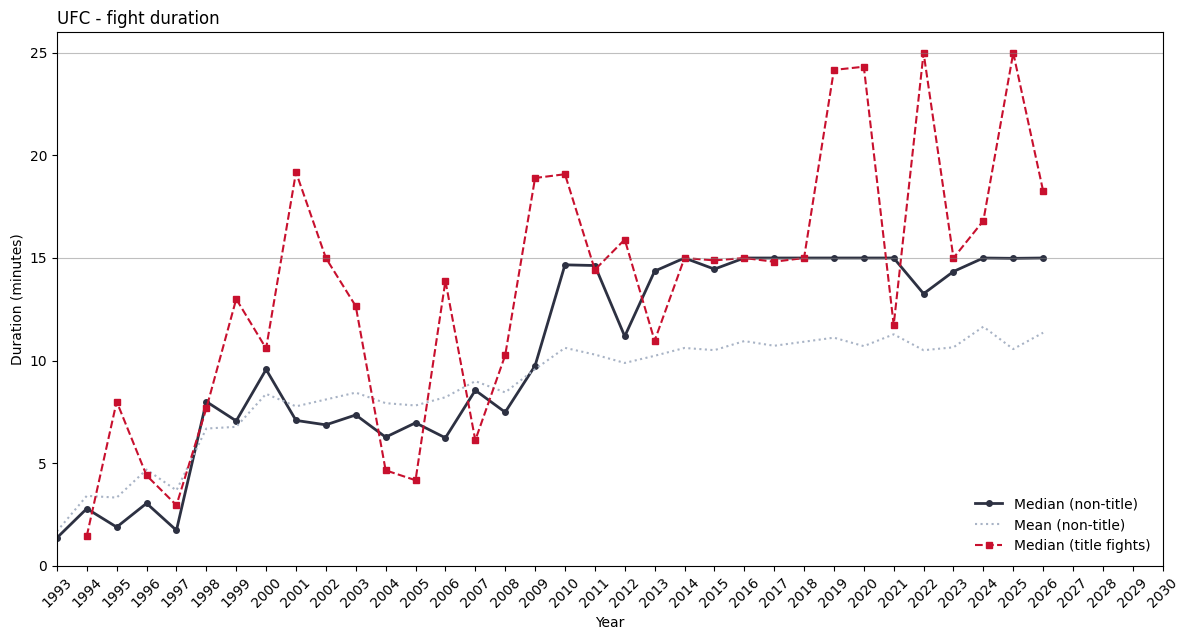

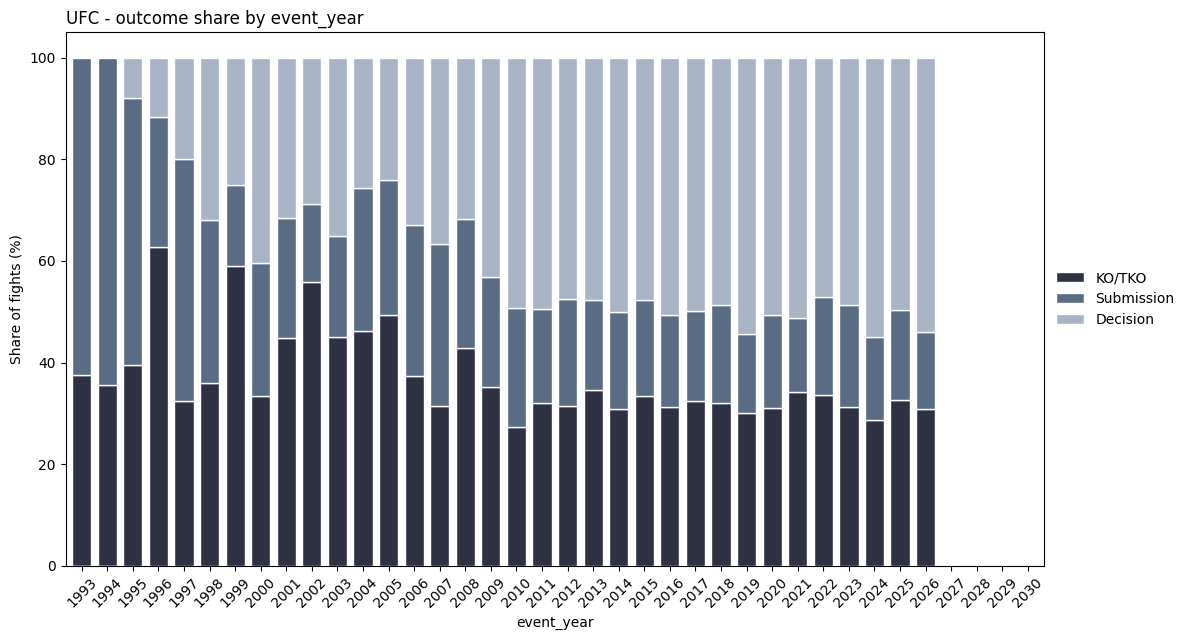

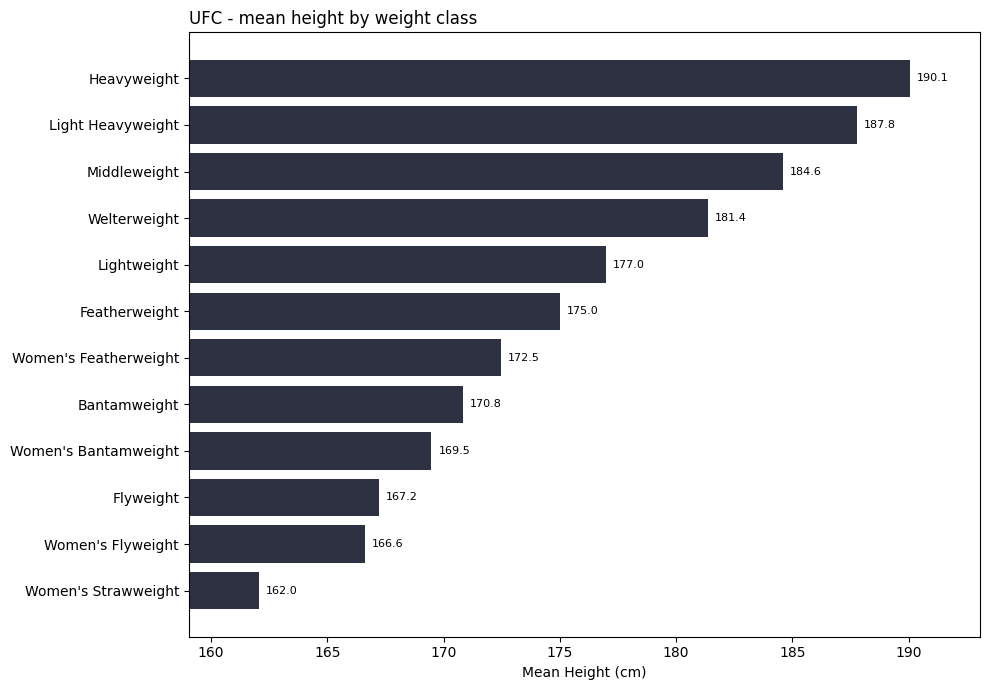

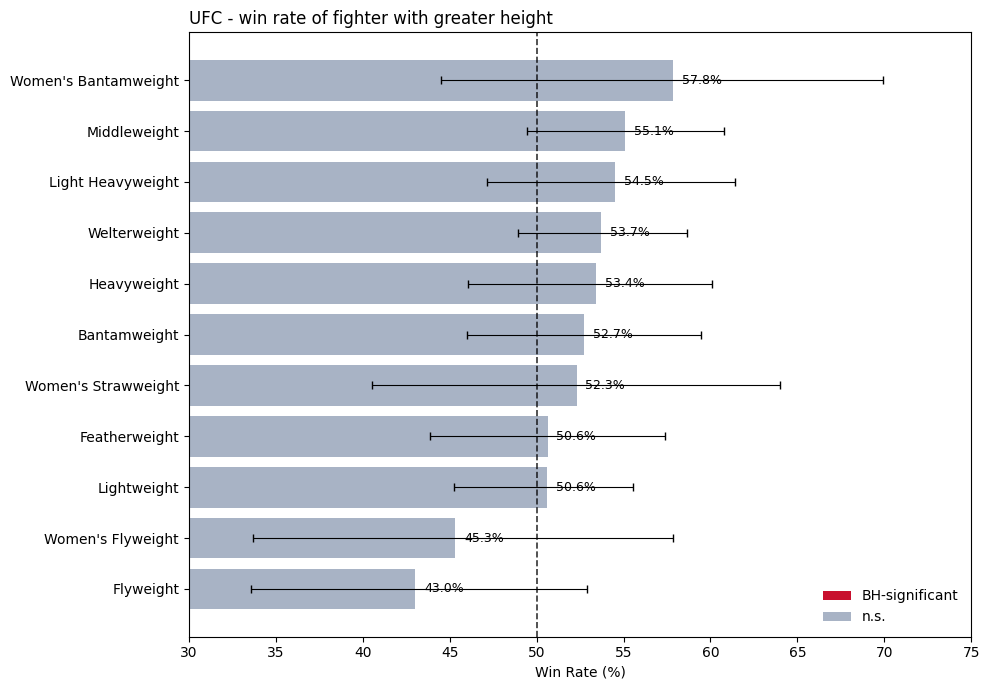

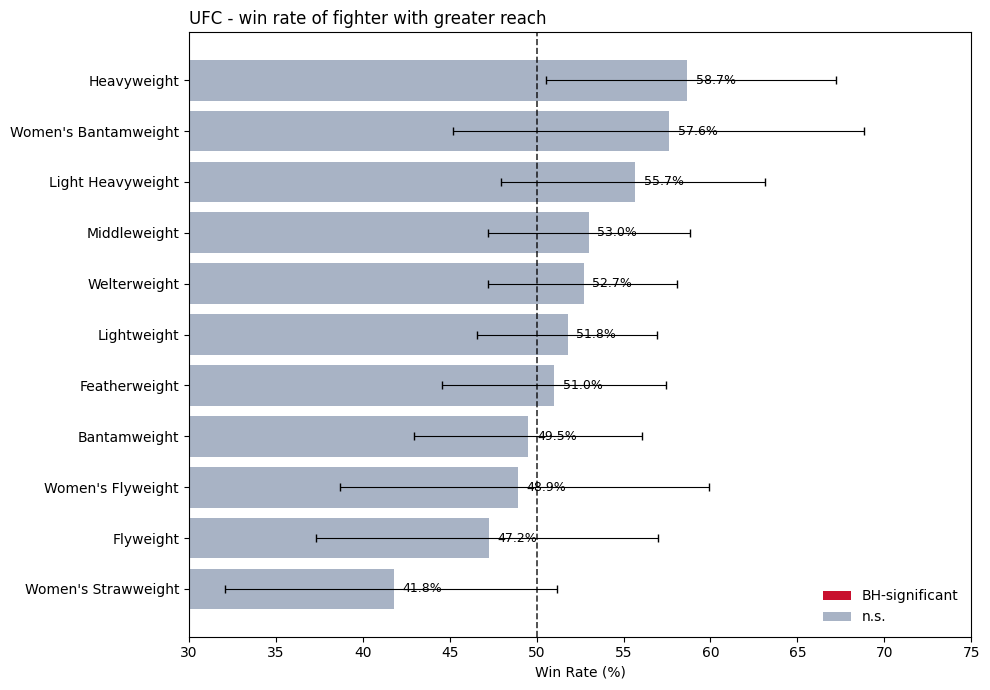


=== SUMMARY ===
Organization  N fights (clean)  Q1 rho    Q1 p  Q1 title median (min)  Q2 chi2  Q2 V Q3 sig (BH) Q4 sig (BH) Q5 sig (BH)
         UFC              8675   0.875 1.3e-11                  14.83    306.2 0.133         0/0        0/11        0/11


In [1]:
from __future__ import annotations
from dataclasses import dataclass, field, replace as dc_replace
from typing import Dict, List, Optional, Tuple
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from statsmodels.stats.multitest import multipletests


@dataclass
class OrganizationConfig:
    name: str
    source: str
    schema_map: Dict[str, str] = field(default_factory=dict)
    excluded_weight_classes: List[str] = field(default_factory=list)
    catchweight_patterns: List[str] = field(
        default_factory=lambda: ["Catchweight", "Catch Weight"]
    )
    has_fight_stats: bool = False
    has_stance: bool = False
    has_reach: bool = False
    has_nationality: bool = False
    has_gym: bool = False
    winner_strategy: str = "explicit"
    winners_json_path: Optional[str] = None
    event_status_filter: Optional[str] = None
    min_obs_per_class: int = 30
    bootstrap_iterations: int = 5000
    bootstrap_seed: int = 42
    fdr_alpha: float = 0.05


UFC_CONFIG = OrganizationConfig(
    name="UFC",
    source="ufcstats",
    schema_map={
        "event_name": "event_name",
        "event_date": "event_date",
        "fighter_1": "fighter_1",
        "fighter_2": "fighter_2",
        "method": "method_raw",
        "round_num": "round_num",
        "time": "round_end_time",
        "weight_class": "weight_class_raw",
        "fight_url": "fight_url",
        "f1_Height_cm": "f1_height_cm",
        "f1_Weight_kg": "f1_weight_kg",
        "f1_Reach_cm": "f1_reach_cm",
        "f1_Stance": "f1_stance",
        "f1_DOB": "f1_dob",
        "f2_Height_cm": "f2_height_cm",
        "f2_Weight_kg": "f2_weight_kg",
        "f2_Reach_cm": "f2_reach_cm",
        "f2_Stance": "f2_stance",
        "f2_DOB": "f2_dob",
        "f1_Sig_str_landed": "f1_sig_str_landed",
        "f2_Sig_str_landed": "f2_sig_str_landed",
        "fighter_1_url": "fighter_1_url",
        "fighter_2_url": "fighter_2_url",
    },
    excluded_weight_classes=["Open Weight", "Catch Weight", "Super Heavyweight"],
    has_fight_stats=True,
    has_stance=True,
    has_reach=True,
    winner_strategy="json",
)


def load_and_adapt(path: str, config: OrganizationConfig) -> pd.DataFrame:
    df = pd.read_csv(path)
    if config.event_status_filter is not None and "event_status" in df.columns:
        df = df[df["event_status"] == config.event_status_filter].copy()
    available_raw = [c for c in config.schema_map.keys() if c in df.columns]
    df = df[available_raw].rename(columns=config.schema_map)
    return df.reset_index(drop=True)


def normalize_method(method_raw) -> str:
    if pd.isna(method_raw):
        return "NoContest"
    m = str(method_raw).strip().lower()
    if "overturned" in m:
        return "Overturned"
    if m == "dq" or "disqualif" in m:
        return "DQ"
    if m.startswith("ko") or m.startswith("tko") or "doctor" in m:
        return "KO/TKO"
    if "decision" in m:
        return "Decision"
    if "submission" in m or m.startswith("submision") or m.startswith("verbal sub"):
        return "Submission"
    return "NoContest"


def normalize_weight_class(wc_raw, catchweight_patterns: List[str]) -> str:
    if pd.isna(wc_raw):
        return "Unknown"
    wc = str(wc_raw).strip()
    wc_lower = wc.lower()
    for p in catchweight_patterns:
        if p.lower() in wc_lower:
            return "Catchweight"
    return wc


def parse_time_to_seconds(t) -> float:
    if pd.isna(t):
        return np.nan
    s = str(t).strip()
    if ":" not in s:
        return np.nan
    parts = s.split(":")
    if len(parts) != 2:
        return np.nan
    try:
        return int(parts[0]) * 60 + int(parts[1])
    except (ValueError, TypeError):
        return np.nan


def _merge_winners_json(df: pd.DataFrame, json_path: str) -> pd.DataFrame:
    if not os.path.exists(json_path):
        df["winner"] = "Unknown"
        df["is_title_fight"] = False
        return df

    with open(json_path, "r", encoding="utf-8") as f:
        winners = json.load(f)

    aux = (pd.DataFrame.from_dict(winners, orient="index")
             .reset_index().rename(columns={"index": "fight_url"}))
    keep = [c for c in ["fight_url", "winner", "is_title_fight"] if c in aux.columns]
    aux = aux[keep]

    df = df.merge(aux, on="fight_url", how="left")
    df["winner"] = df["winner"].fillna("Unknown")
    df["is_title_fight"] = df["is_title_fight"].fillna(False).astype(bool)
    return df


def build_features(df: pd.DataFrame, config: OrganizationConfig) -> pd.DataFrame:
    df = df.copy()

    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce", utc=True).dt.tz_localize(None)
    df = df.dropna(subset=["event_date"]).copy()
    df["event_year"] = df["event_date"].dt.year
    df["event_decade"] = (df["event_year"] // 10 * 10).astype(int).astype(str) + "s"
    df["event_period"] = (df["event_year"] // 5 * 5).astype(int)

    df["round_end_sec"] = df["round_end_time"].apply(parse_time_to_seconds)
    df["fight_duration_sec"] = (df["round_num"] - 1) * 300 + df["round_end_sec"]
    df["fight_duration_min"] = df["fight_duration_sec"] / 60

    df["method_category"] = df["method_raw"].apply(normalize_method)
    df["weight_class"] = df["weight_class_raw"].apply(
        lambda x: normalize_weight_class(x, config.catchweight_patterns)
    )

    # --- LIMPEZA DE DADOS: Removendo aspas/letras de atributos físicos ---
    cols_to_clean = ["f1_height_cm", "f2_height_cm", "f1_weight_kg", "f2_weight_kg", "f1_reach_cm", "f2_reach_cm"]
    for col in cols_to_clean:
        if col in df.columns:
            # Transforma em string, mantém apenas números e ponto, depois converte forçando nulos em falhas
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors="coerce")
    # --------------------------------------------------------------------

    if config.has_fight_stats and {"f1_sig_str_landed", "f2_sig_str_landed"}.issubset(df.columns):
        df["total_sig_str"] = df["f1_sig_str_landed"] + df["f2_sig_str_landed"]
        df["strike_rate_per_min"] = df["total_sig_str"] / df["fight_duration_min"]

    if config.winner_strategy == "json":
        if config.winners_json_path is None:
            df["winner"] = "Unknown"
            df["is_title_fight"] = False
        else:
            df = _merge_winners_json(df, config.winners_json_path)
    elif config.winner_strategy == "explicit":
        if "winner" not in df.columns:
            df["winner"] = "Unknown"
        if "is_title_fight" not in df.columns:
            df["is_title_fight"] = False

    return df.reset_index(drop=True)


def filter_analytical(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["method_category"] != "NoContest"].copy().reset_index(drop=True)


def to_long_fighter_format(df: pd.DataFrame, config: OrganizationConfig) -> pd.DataFrame:
    base_cols = ["event_date", "event_year", "event_decade", "weight_class"]
    f1_cols = ["fighter_1", "fighter_1_url", "f1_height_cm", "f1_weight_kg", "f1_dob"]
    f2_cols = ["fighter_2", "fighter_2_url", "f2_height_cm", "f2_weight_kg", "f2_dob"]
    new_names = ["fighter", "fighter_url", "height_cm", "weight_kg", "dob"]

    if config.has_stance:
        f1_cols.append("f1_stance"); f2_cols.append("f2_stance"); new_names.append("stance")
    if config.has_reach:
        f1_cols.append("f1_reach_cm"); f2_cols.append("f2_reach_cm"); new_names.append("reach_cm")
    if config.has_nationality:
        f1_cols.append("f1_nationality"); f2_cols.append("f2_nationality"); new_names.append("nationality")
    if config.has_gym:
        f1_cols.append("f1_gym"); f2_cols.append("f2_gym"); new_names.append("gym")

    full_cols = base_cols + new_names
    f1 = df[base_cols + f1_cols].copy(); f1.columns = full_cols
    f2 = df[base_cols + f2_cols].copy(); f2.columns = full_cols
    return pd.concat([f1, f2], ignore_index=True)


def apply_bh_correction(pvals: np.ndarray, alpha: float = 0.05) -> Tuple[np.ndarray, np.ndarray]:
    pvals = np.asarray(pvals, dtype=float)
    mask = ~np.isnan(pvals)
    rejected = np.zeros_like(pvals, dtype=bool)
    p_adj = np.full_like(pvals, np.nan, dtype=float)
    if mask.sum() > 0:
        rej_sub, p_adj_sub, _, _ = multipletests(pvals[mask], alpha=alpha, method="fdr_bh")
        rejected[mask] = rej_sub
        p_adj[mask] = p_adj_sub
    return rejected, p_adj


def cluster_bootstrap_proportion(df, outcome_col, cluster_cols, null_value=0.5,
                                  n_boot=5000, seed=42):
    y = df[outcome_col].astype(float).to_numpy()
    n = len(y)
    if n == 0:
        return dict(point=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_value=np.nan,
                    n=0, n_clusters=0, deff=np.nan, n_effective=np.nan, n_boot=0)

    point = float(y.mean())
    fighters = pd.unique(np.concatenate([df[cluster_cols[0]].to_numpy(),
                                         df[cluster_cols[1]].to_numpy()]))
    fid = pd.Series(np.arange(len(fighters)), index=fighters)
    f1_int = fid.loc[df[cluster_cols[0]].to_numpy()].to_numpy()
    f2_int = fid.loc[df[cluster_cols[1]].to_numpy()].to_numpy()
    n_clusters = len(fighters)

    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n_clusters, size=n_clusters)
        counts = np.bincount(idx, minlength=n_clusters)
        w = counts[f1_int] * counts[f2_int]
        s = w.sum()
        boot[b] = (w @ y) / s if s > 0 else np.nan

    boot = boot[~np.isnan(boot)]
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    p_one = float(min((boot >= null_value).mean(), (boot <= null_value).mean()))
    p_two = float(min(1.0, 2.0 * p_one))

    var_naive = (point * (1 - point) / n) if 0 < point < 1 else np.nan
    var_cluster = float(boot.var(ddof=1))
    deff = (var_cluster / var_naive) if (var_naive and var_naive > 0) else np.nan
    n_eff = (n / deff) if (deff and deff > 0) else np.nan

    return dict(
        point=point, ci_lo=float(ci_lo), ci_hi=float(ci_hi),
        p_value=p_two, n=n, n_clusters=n_clusters,
        deff=float(deff) if not np.isnan(deff) else np.nan,
        n_effective=float(n_eff) if not np.isnan(n_eff) else np.nan,
        n_boot=int(len(boot)),
    )


def q1_duration_trend(df: pd.DataFrame) -> dict:
    sub_regular = df[~df["is_title_fight"]].copy()
    sub_elite = df[df["is_title_fight"]].copy()

    yearly_regular = (sub_regular.groupby("event_year")["fight_duration_sec"]
                      .agg(median_regular="median", mean_regular="mean", n_regular="count")
                      .reset_index())
    yearly_elite = (sub_elite.groupby("event_year")["fight_duration_sec"]
                    .agg(median_elite="median", n_elite="count")
                    .reset_index())
    
    yearly = pd.merge(yearly_regular, yearly_elite, on="event_year", how="outer").sort_values("event_year").reset_index(drop=True)

    mask = yearly["median_regular"].notna()
    if mask.sum() > 1:
        rho, p_value = stats.spearmanr(yearly.loc[mask, "event_year"], yearly.loc[mask, "median_regular"])
    else:
        rho, p_value = np.nan, np.nan

    return {
        "question": "Q1: Fight duration trend (is_title_fight strata)",
        "data": yearly,
        "test_name": "Spearman rank correlation (year vs median non-title duration)",
        "rho": float(rho), "p_value": float(p_value),
        "n_fights_regular": int(len(sub_regular)),
        "n_fights_title": int(len(sub_elite)),
        "median_first_year_regular_min": (
            yearly["median_regular"].dropna().iloc[0] / 60 if mask.sum() > 0 else np.nan
        ),
        "median_last_year_regular_min": (
            yearly["median_regular"].dropna().iloc[-1] / 60 if mask.sum() > 0 else np.nan
        ),
        "median_title_overall_min": (
            float(sub_elite["fight_duration_sec"].median() / 60) if len(sub_elite) else np.nan
        ),
    }


def q2_outcome_trend(df: pd.DataFrame, x_var: str = "event_year") -> dict:
    valid = ["KO/TKO", "Submission", "Decision"]
    sub = df[df["method_category"].isin(valid)].copy()
    ct = pd.crosstab(sub[x_var], sub["method_category"])
    cols = [c for c in valid if c in ct.columns]
    ct = ct[cols]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    if ct.shape[0] < 2:
        return {"question": "Q2", "crosstab_count": ct, "crosstab_pct": ct_pct,
                "chi2": np.nan, "p_value": np.nan, "cramers_v": np.nan,
                "note": "single bucket"}

    chi2, p_value, dof, _ = stats.chi2_contingency(ct)
    n = int(ct.sum().sum())
    cramers_v = float(np.sqrt(chi2 / (n * (min(ct.shape) - 1))))

    return {
        "question": "Q2: Outcome distribution over time",
        "x_var": x_var,
        "crosstab_count": ct, "crosstab_pct": ct_pct,
        "test_name": "Chi-square test of independence",
        "chi2": float(chi2), "p_value": float(p_value), "dof": int(dof),
        "cramers_v": cramers_v, "n_fights": n,
    }


def q3_height_trend_by_class(df_fighters: pd.DataFrame, config: OrganizationConfig) -> dict:
    df_q3 = df_fighters[~df_fighters["weight_class"].isin(config.excluded_weight_classes)]
    df_q3 = df_q3[df_q3["weight_class"] != "Catchweight"]
    df_q3 = df_q3.dropna(subset=["height_cm"])

    rows = []
    for wc, g in df_q3.groupby("weight_class"):
        if len(g) < config.min_obs_per_class:
            continue
        rows.append({
            "weight_class": wc,
            "n": int(len(g)),
            "mean_height_cm": float(g["height_cm"].mean()),
        })

    res_df = pd.DataFrame(rows)
    if not res_df.empty:
        res_df = res_df.sort_values("mean_height_cm", ascending=True).reset_index(drop=True)

    return {
        "question": "Q3: Mean height by weight class",
        "results": res_df,
        "n_fighter_appearances": int(len(df_q3)),
        "n_classes_analyzed": int(len(res_df)),
    }


def _winrate_engine(df, metric_cols, config, label):
    col1, col2 = metric_cols

    if "winner" not in df.columns or (df["winner"] == "Unknown").all():
        return {"question": label, "results": pd.DataFrame(),
                "error": "Coluna 'winner' ausente ou totalmente 'Unknown'."}

    sub = df[~df["winner"].isin(["Draw/NC", "Unknown"])].copy()
    sub = sub.dropna(subset=["winner", col1, col2, "fighter_1_url", "fighter_2_url"])

    n_before_ties = len(sub)
    sub = sub[sub[col1] != sub[col2]].copy()
    n_excluded_ties = int(n_before_ties - len(sub))
    pct_excluded_ties = (n_excluded_ties / n_before_ties * 100) if n_before_ties else 0.0

    f1_taller = sub[col1] > sub[col2]
    f1_winner = sub["winner"] == sub["fighter_1"]
    sub["taller_won"] = ((f1_taller & f1_winner) | (~f1_taller & ~f1_winner)).astype(int)

    rows = []
    for wc, g in sub.groupby("weight_class"):
        if wc in config.excluded_weight_classes or wc == "Catchweight":
            continue
        if len(g) < config.min_obs_per_class:
            continue
        b = cluster_bootstrap_proportion(
            df=g, outcome_col="taller_won",
            cluster_cols=["fighter_1_url", "fighter_2_url"],
            null_value=0.5,
            n_boot=config.bootstrap_iterations,
            seed=config.bootstrap_seed,
        )
        rows.append({
            "weight_class": wc,
            "n": b["n"], "n_clusters_fighters": b["n_clusters"],
            "win_rate": b["point"],
            "ci_lo": b["ci_lo"], "ci_hi": b["ci_hi"],
            "p_value_raw": b["p_value"],
            "deff": b["deff"], "n_effective": b["n_effective"],
        })

    res_df = pd.DataFrame(rows)
    if not res_df.empty:
        rejected, p_adj = apply_bh_correction(res_df["p_value_raw"].to_numpy(), alpha=config.fdr_alpha)
        res_df["p_value_bh"] = p_adj
        res_df["significant_bh"] = rejected
        res_df = res_df.sort_values("win_rate", ascending=True).reset_index(drop=True)

    return {
        "question": label,
        "results": res_df,
        "n_fights_analyzed": int(len(sub)),
        "n_excluded_ties": n_excluded_ties,
        "pct_excluded_ties": float(pct_excluded_ties),
        "taxa_geral": float(sub["taller_won"].mean()) if len(sub) > 0 else np.nan,
    }


def q4_taller_win_rate(df: pd.DataFrame, config: OrganizationConfig) -> dict:
    return _winrate_engine(
        df=df, metric_cols=("f1_height_cm", "f2_height_cm"), config=config,
        label="Q4: Win rate of taller fighter (cluster bootstrap + BH)",
    )


def q5_reach_win_rate(df: pd.DataFrame, config: OrganizationConfig) -> dict:
    if not config.has_reach:
        return {"question": "Q5", "results": pd.DataFrame(),
                "error": f"{config.name}: sem dados de reach."}
    return _winrate_engine(
        df=df, metric_cols=("f1_reach_cm", "f2_reach_cm"), config=config,
        label="Q5: Win rate of longer-reach fighter (cluster bootstrap + BH)",
    )


HIGHLIGHT = "#C8102E"
PRIMARY = "#2d3142"
SECONDARY = "#5a6c84"
TERTIARY = "#a8b3c5"


def _add_description(fig, description=None):
    if not description:
        return
    fig.subplots_adjust(bottom=0.25)
    fig.text(0.5, 0.02, description, wrap=True,
             horizontalalignment="center", fontsize=10, color="#444444")


def plot_duration_trend(result, org_name="", description=None, ax=None):
    yearly = result["data"]
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6.5))
    else:
        fig = ax.get_figure()

    # Filtra os NaNs para a linha não quebrar se faltar algum ano
    reg = yearly.dropna(subset=["median_regular", "mean_regular"])
    ax.plot(reg["event_year"], reg["median_regular"] / 60,
            color=PRIMARY, linewidth=2, marker="o", markersize=4,
            label="Median (non-title)")
    ax.plot(reg["event_year"], reg["mean_regular"] / 60,
            color=TERTIARY, linewidth=1.5, linestyle=":",
            label="Mean (non-title)")
            
    elite = yearly[["event_year", "median_elite"]].dropna()
    if not elite.empty:
        ax.plot(elite["event_year"], elite["median_elite"] / 60,
                color=HIGHLIGHT, linewidth=1.5, linestyle="--",
                marker="s", markersize=4, label="Median (title fights)")

    ax.axhline(15, color="gray", linewidth=0.8, alpha=0.5)
    ax.axhline(25, color="gray", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Year"); ax.set_ylabel("Duration (minutes)")
    ax.set_yticks(np.arange(0, 26, 5))
    ax.set_ylim(0, 26)

    ax.set_xticks(np.arange(1993, 2031, 1))
    ax.set_xlim(1993, 2030)
    ax.tick_params(axis='x', rotation=45)

    ax.set_title(f"{org_name} - fight duration" if org_name else "Fight duration over time",
                 loc="left")
    ax.legend(frameon=False)
    plt.tight_layout()
    _add_description(fig, description)


def plot_outcome_stack(result, org_name="", description=None, ax=None):
    pct = result["crosstab_pct"]

    todos_os_anos = np.arange(1993, 2031, 1)
    pct = pct.reindex(todos_os_anos, fill_value=0)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6.5))
    else:
        fig = ax.get_figure()

    pct.plot(kind="bar", stacked=True, ax=ax,
             color=[PRIMARY, SECONDARY, TERTIARY],
             width=0.75, edgecolor="white", linewidth=1.0)

    xv = result.get("x_var", "period")
    ax.set_xlabel(xv); ax.set_ylabel("Share of fights (%)")
    title = f"{org_name} - outcome share by {xv}" if org_name else f"Outcome share by {xv}"
    ax.set_title(title, loc="left")

    ax.set_xticklabels(pct.index, rotation=45)

    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
    plt.tight_layout()
    _add_description(fig, description)


def plot_height_slopes(result, org_name="", description=None, ax=None):
    df = result["results"]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
    else:
        fig = ax.get_figure()

    bars = ax.barh(df["weight_class"], df["mean_height_cm"], color=PRIMARY, edgecolor="none")
    ax.set_xlabel("Mean Height (cm)")
    ax.set_title(f"{org_name} - mean height by weight class" if org_name else "Mean height by weight class",
                 loc="left")

    if len(df):
        ax.set_xlim(df["mean_height_cm"].min() - 3, df["mean_height_cm"].max() + 3)

    for bar, (_, row) in zip(bars, df.iterrows()):
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{w:.1f}", va="center", ha="left", fontsize=8)

    plt.tight_layout()
    _add_description(fig, description)


def _plot_winrate(result, org_name, metric_label, description=None, ax=None):
    if "error" in result:
        return
    df = result["results"]
    if df.empty:
        return
    sig_col = "significant_bh" if "significant_bh" in df.columns else "significant"
    colors = [HIGHLIGHT if s else TERTIARY for s in df[sig_col]]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
    else:
        fig = ax.get_figure()

    win_pct = df["win_rate"] * 100
    bars = ax.barh(df["weight_class"], win_pct, color=colors, edgecolor="none")
    if {"ci_lo", "ci_hi"}.issubset(df.columns):
        err_lo = (df["win_rate"] - df["ci_lo"]) * 100
        err_hi = (df["ci_hi"] - df["win_rate"]) * 100
        ax.errorbar(win_pct, df["weight_class"], xerr=[err_lo, err_hi],
                    fmt="none", ecolor="black", elinewidth=0.8, capsize=3)
    ax.axvline(50, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_xlabel("Win Rate (%)"); ax.set_xlim(30, 75)
    ax.set_title(f"{org_name} - win rate of fighter with greater {metric_label}", loc="left")
    for bar, (_, row) in zip(bars, df.iterrows()):
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{w:.1f}%", va="center", ha="left", fontsize=9)
    ax.legend(handles=[Patch(facecolor=HIGHLIGHT, label="BH-significant"),
                       Patch(facecolor=TERTIARY, label="n.s.")],
              loc="lower right", frameon=False)
    plt.tight_layout()
    _add_description(fig, description)


def plot_taller_win_rate(result, org_name="", description=None, ax=None):
    _plot_winrate(result, org_name, "height", description, ax)


def plot_reach_win_rate(result, org_name="", description=None, ax=None):
    _plot_winrate(result, org_name, "reach", description, ax)


def run_core_pipeline(csv_path, config, winners_json_path=None):
    if winners_json_path is not None:
        config = dc_replace(config, winners_json_path=winners_json_path)
    df = load_and_adapt(csv_path, config)
    df = build_features(df, config)
    df_clean = filter_analytical(df)
    df_fighters = to_long_fighter_format(df_clean, config)
    return {
        "config": config,
        "df": df_clean,
        "df_fighters": df_fighters,
        "q1": q1_duration_trend(df_clean),
        "q2": q2_outcome_trend(df_clean, x_var="event_year"),
        "q3": q3_height_trend_by_class(df_fighters, config),
        "q4": q4_taller_win_rate(df_clean, config),
        "q5": q5_reach_win_rate(df_clean, config),
    }


def build_summary_table(pipeline_result):
    config = pipeline_result["config"]
    q1, q2 = pipeline_result["q1"], pipeline_result["q2"]
    q3, q4, q5 = pipeline_result["q3"], pipeline_result["q4"], pipeline_result["q5"]

    def _sig(qres):
        r = qres.get("results")
        if not isinstance(r, pd.DataFrame) or r.empty or "significant_bh" not in r.columns:
            return 0, 0
        return int(r["significant_bh"].sum()), int(len(r))

    s3, t3 = _sig(q3); s4, t4 = _sig(q4); s5, t5 = _sig(q5)

    return pd.DataFrame([{
        "Organization": config.name,
        "N fights (clean)": len(pipeline_result["df"]),
        "Q1 rho": round(q1["rho"], 3) if not pd.isna(q1["rho"]) else np.nan,
        "Q1 p": f"{q1['p_value']:.2g}" if not pd.isna(q1['p_value']) else "NaN",
        "Q1 title median (min)": round(q1.get("median_title_overall_min", np.nan), 2),
        "Q2 chi2": round(q2["chi2"], 1),
        "Q2 V": round(q2["cramers_v"], 3),
        "Q3 sig (BH)": f"{s3}/{t3}",
        "Q4 sig (BH)": f"{s4}/{t4}",
        "Q5 sig (BH)": f"{s5}/{t5}",
    }])


if __name__ == "__main__":
    resultados = run_core_pipeline(
        csv_path="/kaggle/input/datasets/leandroiber/ufc-stats-complete-dataset/clean_ufc_dataset.csv",
        config=UFC_CONFIG,
        winners_json_path="/kaggle/input/datasets/leandroiber/ufc-stats-complete-dataset/win_and_title_data-ufc.json"
    )

    df_clean = resultados["df"]
    q1, q2, q3, q4, q5 = resultados["q1"], resultados["q2"], resultados["q3"], resultados["q4"], resultados["q5"]

    print(f"Lutas analiticas: {len(df_clean)} | "
          f"Periodo: {int(df_clean['event_year'].min())}-{int(df_clean['event_year'].max())}")
    print(f"Title fights: {int(df_clean['is_title_fight'].sum())} | "
          f"Non-title: {int((~df_clean['is_title_fight']).sum())}")

    print(f"\n[Q1] Spearman (year vs median non-title duration): "
          f"rho={q1['rho']:.3f}, p={q1['p_value']:.4g}")
    print(f"     Median non-title (primeiro/ultimo ano): "
          f"{q1['median_first_year_regular_min']:.2f} -> {q1['median_last_year_regular_min']:.2f} min")
    print(f"     Median title overall: {q1['median_title_overall_min']:.2f} min")

    print(f"\n[Q2] Qui-quadrado de independencia (year x method): "
          f"chi2={q2['chi2']:.2f}, p={q2['p_value']:.4g}, "
          f"V de Cramer={q2['cramers_v']:.3f}, n={q2['n_fights']}")

    print(f"\n[Q3] Classes analisadas: {q3['n_classes_analyzed']} | "
          f"N total fighter-appearances: {q3['n_fighter_appearances']}")
    print(q3["results"].round(2).to_string(index=False))

    if "error" in q4:
        print(f"\n[Q4] {q4['error']}")
    else:
        print(f"\n[Q4] Win rate do mais alto | n_fights={q4['n_fights_analyzed']} | "
              f"ties excluidos={q4['n_excluded_ties']} ({q4['pct_excluded_ties']:.1f}%) | "
              f"taxa geral={q4['taxa_geral']:.3f}")
        cols_q4 = ["weight_class", "n", "win_rate", "ci_lo", "ci_hi",
                   "p_value_raw", "p_value_bh", "significant_bh"]
        print(q4["results"][cols_q4].round(4).to_string(index=False))

    if "error" in q5:
        print(f"\n[Q5] {q5['error']}")
    else:
        print(f"\n[Q5] Win rate do maior reach | n_fights={q5['n_fights_analyzed']} | "
              f"ties excluidos={q5['n_excluded_ties']} ({q5['pct_excluded_ties']:.1f}%) | "
              f"taxa geral={q5['taxa_geral']:.3f}")
        cols_q5 = ["weight_class", "n", "win_rate", "ci_lo", "ci_hi",
                   "p_value_raw", "p_value_bh", "significant_bh"]
        print(q5["results"][cols_q5].round(4).to_string(index=False))

    plot_duration_trend(q1, org_name=resultados["config"].name)
    plt.savefig("/kaggle/working/q1_ufc_duration.png", dpi=120, bbox_inches="tight")
    plt.show()

    plot_outcome_stack(q2, org_name=resultados["config"].name)
    plt.savefig("/kaggle/working/q2_ufc_outcomes.png", dpi=120, bbox_inches="tight")
    plt.show()

    plot_height_slopes(q3, org_name=resultados["config"].name)
    plt.savefig("/kaggle/working/q3_ufc_height.png", dpi=120, bbox_inches="tight")
    plt.show()

    plot_taller_win_rate(q4, org_name=resultados["config"].name)
    plt.savefig("/kaggle/working/q4_ufc_height_winrate.png", dpi=120, bbox_inches="tight")
    plt.show()

    if resultados["config"].has_reach:
        plot_reach_win_rate(q5, org_name=resultados["config"].name)
        plt.savefig("/kaggle/working/q5_ufc_reach_winrate.png", dpi=120, bbox_inches="tight")
        plt.show()

    print("\n=== SUMMARY ===")
    print(build_summary_table(resultados).to_string(index=False))

## Q1 - Fight Duration Over Time (UFC - fight duration)
Looking at the fight duration timeline, the introduction of the Unified Rules in 2001 clearly splits the data into two distinct eras. During the first seven years, the UFC lacked weight classes (until 1997), scorecards, rounds, and consistent time limits. Fighters often competed multiple times in a single night, and matchmakers focused on putting different martial arts styles against one another. Bouts could end in two minutes, like Royce vs. Jimmerson, or drag on for 36 minutes, as seen in Royce vs. Ken Shamrock. Because of these shifting rules, varying fighter backgrounds, and small annual samples, both the mean and median durations swing wildly across the early graph. Royce Gracie is a prime example of this chaos, submitting multiple opponents in a single night at UFC 1 and UFC 2 despite weighing around 80 kg in an open-weight bracket.

The late 90s saw transitional volatility as the UFC tried to appease regulators. Then, Zuffa bought the promotion in 2001 and adopted the Unified Rules. From that point on, the median duration climbs steadily through the 2000s and flattens out at exactly 15 minutes over the last decade. Since regular fights max out at 15 minutes (three five-minute rounds), this median plateau is a direct result of more than half of all bouts now going the distance. The mean stays around 10 to 11 minutes because quick finishes pull the average down. For five-round title fights, the median also frequently hits its 25-minute cap. While title bout data is jumpier due to the small sample size, fighting to the final bell is now the most common outcome across all card levels.

## Q2 - Outcome Distribution Over Time (UFC - outcome share by event_year)
Match results directly drive the duration trends we see above. In 1993, with no judges or real time limits, there were zero decisions. Submissions peaked heavily in 1994. Back then, pure strikers lacked grappling defense, making submissions an easy path to victory for ground specialists.

The 2001 Unified Rules changed the landscape. Time limits brought in scorecards, but athletes also evolved. As fighters rounded out their defensive abilities across the board, the submission rate steadily dropped throughout the 2000s. By 2010, the numbers settled: decisions happen in about 50% of bouts, knockouts sit between 30% and 35%, and submissions have shrunk to 15% to 20%. Modern fighters are simply harder to finish, which locks in the 15-minute decision as the standard UFC bout.

## Q3 - Mean Height by Weight Class (UFC - mean height by weight class)
Average fighter height scales reliably alongside weight class limits, climbing about 3 to 4 centimeters per division from 167.2 cm at Flyweight to 190.1 cm at Heavyweight. Fighters severely dehydrate themselves for weigh-ins to compete with the largest possible frame and reach for their given category.
The Heavyweight data requires a closer look. While the historical average is 190.1 cm, the division is getting taller. It is crucial to highlight that this 195 cm average specifically reflects the current UFC top 5, showing a clear physical escalation among the division's elite.

Women's divisions show a similar progression, moving from 161.6 cm at Strawweight to 172.0 cm at Featherweight. Establishing these baselines helps us evaluate whether being taller than average actually helps a fighter win.

## Q4 - Win Rate by Height Advantage (UFC - win rate of fighter with greater height)
Many assume being taller provides an edge, but the data does not back that up. Looking at the 50% win rate line (essentially a coin flip), some point estimates lean toward the taller fighter (like Women's Bantamweight at 58.1%) and others favor the shorter one (Flyweight at 42.8%). However, the horizontal error bars for every single weight class cross that 50% mark. After applying the Benjamini-Hochberg correction, none of the height advantages show statistical significance. Being the taller fighter simply doesn't reliably boost the odds of winning. Shorter fighters bring counter-advantages to the cage, like a lower center of gravity for takedown defense or better inside boxing mechanics.

## Q5 - Win Rate by Reach Advantage (UFC - win rate of fighter with greater reach)
Reach tells a very similar story. In most weight classes, the win rate for the longer-armed fighter sits right around 50%, with confidence intervals crossing the neutral line just like the height metrics. A longer reach helps manage distance, but shorter frames often generate faster inside strikes and tighter grappling leverage. In some cases, like Women's Strawweight (41.8%), the shorter reach even holds a slight edge.